# Loss Function Demo

File này ghi lại các **hàm Python** để tính và biểu diễn các loss function phổ biến:

- MSE
- RMSE
- MAE
- Cross Entropy
- Huber Loss

Ý tưởng chung: **Loss function đo mức độ sai lệch giữa giá trị thật `y_true` và giá trị dự đoán `y_pred`.**  
Loss càng nhỏ thì model dự đoán càng gần thực tế.


## 1. Import thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Chuẩn bị dữ liệu ví dụ

Giả sử ta có giá trị thật và giá trị model dự đoán như sau:


In [2]:
y_true = np.array([3, 5, 7, 9, 11])
y_pred = np.array([2.5, 5.5, 6.0, 10.0, 12.5])

print("y_true:", y_true)
print("y_pred:", y_pred)
print("error:", y_true - y_pred)

y_true: [ 3  5  7  9 11]
y_pred: [ 2.5  5.5  6.  10.  12.5]
error: [ 0.5 -0.5  1.  -1.  -1.5]


# A. MSE - Mean Squared Error

MSE lấy sai số, bình phương lên, rồi tính trung bình.

Công thức:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Đặc điểm: phạt mạnh các lỗi lớn vì có bình phương.


In [3]:
def mse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean((y_true - y_pred) ** 2)

mse_value = mse(y_true, y_pred)
print("MSE =", mse_value)

MSE = 0.95


# B. RMSE - Root Mean Squared Error

RMSE là căn bậc hai của MSE.

Công thức:

$$
RMSE = \sqrt{MSE}
$$

Đặc điểm: dễ hiểu hơn MSE vì đơn vị của RMSE giống với đơn vị của dữ liệu gốc.


In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

rmse_value = rmse(y_true, y_pred)
print("RMSE =", rmse_value)

RMSE = 0.9746794344808963


# C. MAE - Mean Absolute Error

MAE lấy trị tuyệt đối của sai số, rồi tính trung bình.

Công thức:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Đặc điểm: dễ hiểu, ít bị ảnh hưởng bởi lỗi cực lớn hơn MSE.


In [5]:
def mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

mae_value = mae(y_true, y_pred)
print("MAE =", mae_value)

MAE = 0.9


# D. Cross Entropy

Cross Entropy thường dùng cho bài toán **classification**.

Ví dụ binary classification:

- `y_true = 1`: thực tế là class 1
- `y_true = 0`: thực tế là class 0
- `y_pred`: xác suất model dự đoán class 1

Công thức Binary Cross Entropy:

$$
BCE = -\frac{1}{n}\sum_{i=1}^{n}[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]
$$

Nếu model dự đoán xác suất càng sai, loss càng lớn.


In [6]:
def binary_cross_entropy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # tránh lỗi log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Ví dụ classification
y_true_class = np.array([1, 0, 1, 1, 0])
y_pred_prob = np.array([0.9, 0.2, 0.8, 0.4, 0.1])

bce_value = binary_cross_entropy(y_true_class, y_pred_prob)

print("y_true_class:", y_true_class)
print("y_pred_prob:", y_pred_prob)
print("Binary Cross Entropy =", bce_value)

y_true_class: [1 0 1 1 0]
y_pred_prob: [0.9 0.2 0.8 0.4 0.1]
Binary Cross Entropy = 0.31465977316364546


# E. Huber Loss

Huber Loss là sự kết hợp giữa MSE và MAE.

- Nếu lỗi nhỏ: xử lý giống MSE
- Nếu lỗi lớn: xử lý giống MAE

Công thức:

$$
L_\delta(a)=
\begin{cases}
\frac{1}{2}a^2, & \text{nếu } |a| \leq \delta \\
\delta(|a| - \frac{1}{2}\delta), & \text{nếu } |a| > \delta
\end{cases}
$$

Trong đó:

$$
a = y - \hat{y}
$$

Huber Loss hữu ích khi dữ liệu có outlier.


In [7]:
def huber_loss(y_true, y_pred, delta=1.0):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    error = y_true - y_pred
    abs_error = np.abs(error)

    loss = np.where(
        abs_error <= delta,
        0.5 * error ** 2,
        delta * (abs_error - 0.5 * delta)
    )

    return np.mean(loss)

huber_value = huber_loss(y_true, y_pred, delta=1.0)
print("Huber Loss =", huber_value)

Huber Loss = 0.45


## 3. So sánh các loss function trên cùng dữ liệu

In [8]:
print("MSE        =", mse(y_true, y_pred))
print("RMSE       =", rmse(y_true, y_pred))
print("MAE        =", mae(y_true, y_pred))
print("Huber Loss =", huber_loss(y_true, y_pred, delta=1.0))

MSE        = 0.95
RMSE       = 0.9746794344808963
MAE        = 0.9
Huber Loss = 0.45


## 4. Vẽ biểu đồ loss theo sai số

Ta sẽ tạo nhiều mức sai số khác nhau để xem từng loss function phản ứng như thế nào.


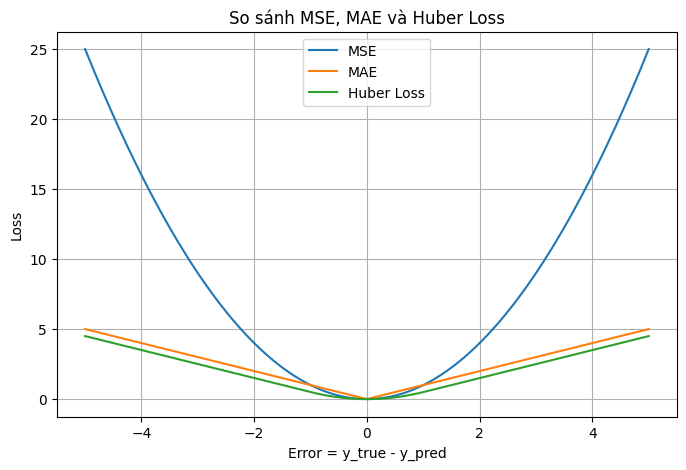

In [9]:
errors = np.linspace(-5, 5, 200)

mse_losses = errors ** 2
mae_losses = np.abs(errors)

delta = 1.0
huber_losses = np.where(
    np.abs(errors) <= delta,
    0.5 * errors ** 2,
    delta * (np.abs(errors) - 0.5 * delta)
)

plt.figure(figsize=(8, 5))
plt.plot(errors, mse_losses, label="MSE")
plt.plot(errors, mae_losses, label="MAE")
plt.plot(errors, huber_losses, label="Huber Loss")
plt.xlabel("Error = y_true - y_pred")
plt.ylabel("Loss")
plt.title("So sánh MSE, MAE và Huber Loss")
plt.legend()
plt.grid(True)
plt.show()

## 5. Vẽ Binary Cross Entropy theo xác suất dự đoán

Giả sử giá trị thật là `1`.  
Nếu model dự đoán xác suất gần `1`, loss nhỏ.  
Nếu model dự đoán xác suất gần `0`, loss rất lớn.


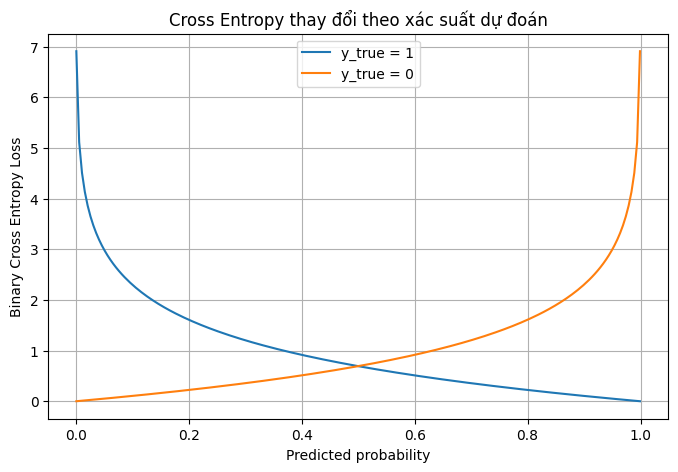

In [10]:
probabilities = np.linspace(0.001, 0.999, 200)

bce_when_true_1 = -np.log(probabilities)
bce_when_true_0 = -np.log(1 - probabilities)

plt.figure(figsize=(8, 5))
plt.plot(probabilities, bce_when_true_1, label="y_true = 1")
plt.plot(probabilities, bce_when_true_0, label="y_true = 0")
plt.xlabel("Predicted probability")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Cross Entropy thay đổi theo xác suất dự đoán")
plt.legend()
plt.grid(True)
plt.show()

## 6. Bài tập nhỏ

### Bài 1
Cho dữ liệu:

```python
y_true = [10, 20, 30, 40]
y_pred = [12, 18, 33, 37]
```

Hãy tính:

- MSE
- RMSE
- MAE
- Huber Loss

### Bài 2
Cho bài toán classification:

```python
y_true = [1, 0, 1, 0]
y_pred = [0.8, 0.3, 0.6, 0.2]
```

Hãy tính Binary Cross Entropy.


In [11]:
# Bài 1
y_true_ex1 = [10, 20, 30, 40]
y_pred_ex1 = [12, 18, 33, 37]

print("Bài 1")
print("MSE        =", mse(y_true_ex1, y_pred_ex1))
print("RMSE       =", rmse(y_true_ex1, y_pred_ex1))
print("MAE        =", mae(y_true_ex1, y_pred_ex1))
print("Huber Loss =", huber_loss(y_true_ex1, y_pred_ex1, delta=1.0))

# Bài 2
y_true_ex2 = [1, 0, 1, 0]
y_pred_ex2 = [0.8, 0.3, 0.6, 0.2]

print("\nBài 2")
print("Binary Cross Entropy =", binary_cross_entropy(y_true_ex2, y_pred_ex2))

Bài 1
MSE        = 6.5
RMSE       = 2.5495097567963922
MAE        = 2.5
Huber Loss = 2.0

Bài 2
Binary Cross Entropy = 0.32844691758328565


## 7. Tóm tắt nhanh

| Loss Function | Dùng cho | Ý nghĩa chính |
|---|---|---|
| MSE | Regression | Phạt lỗi lớn rất mạnh |
| RMSE | Regression | Giống MSE nhưng dễ hiểu hơn vì cùng đơn vị với dữ liệu |
| MAE | Regression | Trung bình độ lệch tuyệt đối |
| Cross Entropy | Classification | Đo độ sai của xác suất dự đoán |
| Huber Loss | Regression có outlier | Kết hợp điểm mạnh của MSE và MAE |
